In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
data=sns.load_dataset('titanic')

In [41]:
data['age']=data['age'].fillna(data['age'].median())
data['sex']=data['sex'].map({'male': 0, 'female': 1})
data['family_size']=data['sibsp']+data['parch']+1
x=data[['pclass','sex','age','fare','family_size']]
y=data['survived']

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"训练集大小：{x_train.shape}")
print(f"测试集大小：{x_test.shape}")
print(f"训练集标签大小：{y_train.shape}")
print(f"测试集标签大小：{y_test.shape}")

训练集大小：(712, 5)
测试集大小：(179, 5)
训练集标签大小：(712,)
测试集标签大小：(179,)


模型在测试集上的准确率:0.8045
混淆矩阵(实际vs预期):
[[92 13]
 [22 52]]


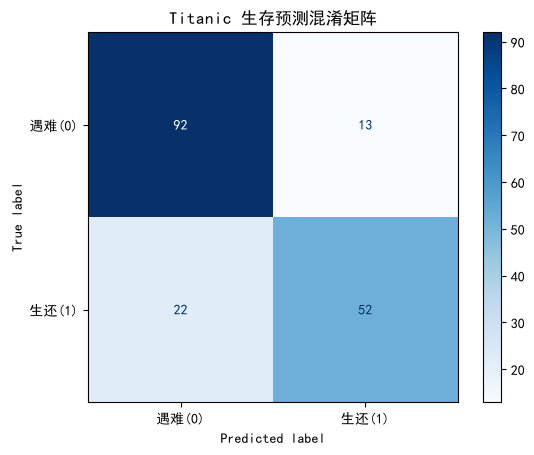

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model=LogisticRegression(max_iter=10000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
print(f"模型在测试集上的准确率:{acc:.4f}")
cm=confusion_matrix(y_test,y_pred)
print("混淆矩阵(实际vs预期):")
print(cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['遇难(0)','生还(1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Titanic 生存预测混淆矩阵")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
plt.show()